# GridOps Copilot — FRA 1D CNN training on AMD ROCm

This notebook trains the five-class FRA model used by the FastAPI backend. It is designed to run from the repository's `notebooks/` directory in an AMD AI Notebooks / AMD Developer Cloud Jupyter session.

Before running all cells:

1. Confirm the repository includes `data/synthetic/` and that the kernel working directory is `notebooks/`.
2. Select the AMD ROCm PyTorch kernel/image. Do **not** install a generic CUDA PyTorch wheel over the ROCm build.
3. If needed, install only the lightweight helpers with `pip install pandas numpy scikit-learn matplotlib`.
4. Run all cells, inspect the grouped synthetic holdout metrics, then download/commit the generated artifact and evidence files. These metrics use unseen seeded scenario groups, but they do **not** estimate field generalization.
5. Stop the AMD GPU session after saving screenshots and artifacts.

Official AMD evidence and `fra_cnn_rocm.pt` are exported only when both a PyTorch GPU and a non-empty HIP runtime version are detected. A CPU/non-ROCm run is only a smoke test and cannot create or overwrite AMD evidence. The model is decision support only and always requires qualified engineer review.

In [1]:
import json
import os
import platform
import random
from datetime import datetime, timezone
from pathlib import Path

import torch

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != "notebooks":
    raise RuntimeError(
        "Run this notebook with the kernel working directory set to the repository's "
        "notebooks/ directory."
    )
REPO_ROOT = NOTEBOOK_DIR.parent

GPU_AVAILABLE = bool(torch.cuda.is_available())
HIP_VERSION = getattr(torch.version, "hip", None)
AMD_ROCM_READY = GPU_AVAILABLE and bool(HIP_VERSION)
DEVICE_NAME = torch.cuda.get_device_name(0) if GPU_AVAILABLE else None
DEVICE = torch.device("cuda" if GPU_AVAILABLE else "cpu")

ENVIRONMENT = {
    "captured_at": datetime.now(timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "hip_version": HIP_VERSION,
    "gpu_available": GPU_AVAILABLE,
    "gpu_count": torch.cuda.device_count() if GPU_AVAILABLE else 0,
    "device_name": DEVICE_NAME,
    "amd_rocm_verified": AMD_ROCM_READY,
}
print(json.dumps(ENVIRONMENT, indent=2))

if AMD_ROCM_READY:
    print(f"Verified ROCm/HIP accelerator: {DEVICE_NAME}")
elif GPU_AVAILABLE:
    print("A GPU is visible, but torch.version.hip is empty; AMD evidence export is disabled.")
else:
    print("No GPU detected. CPU smoke testing is allowed, but AMD evidence export is disabled.")

{
  "captured_at": "2026-07-11T11:24:03.506977+00:00",
  "python_version": "3.10.12",
  "platform": "Linux-6.8.0-79-generic-x86_64-with-glibc2.35",
  "torch_version": "2.9.1+gitff65f5b",
  "hip_version": "7.2.53211-e1a6bc5663",
  "gpu_available": true,
  "gpu_count": 1,
  "device_name": "",
  "amd_rocm_verified": true
}
Verified ROCm/HIP accelerator: 


In [2]:
import hashlib
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch.nn as nn
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

SEED = 42
SEQUENCE_LENGTH = 256
SCENARIOS_PER_CLASS = 12
OBSERVATIONS_PER_SCENARIO = 4
BATCH_SIZE = 32
EPOCHS = 24

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if GPU_AVAILABLE:
    torch.cuda.manual_seed_all(SEED)

LABELS = (
    "healthy",
    "winding_deformation_suspected",
    "core_clamping_issue_suspected",
    "insulation_related_abnormality_suspected",
    "needs_human_review",
)
LABEL_TO_INDEX = {label: index for index, label in enumerate(LABELS)}
INDEX_TO_LABEL = {str(index): label for index, label in enumerate(LABELS)}
REQUIRED_COLUMNS = ("frequency_hz", "magnitude_db", "phase_deg")

In [3]:
DATA_DIR = REPO_ROOT / "data" / "synthetic"
CANONICAL_FILES = {
    "healthy": DATA_DIR / "fra_healthy.csv",
    "winding_deformation_suspected": DATA_DIR / "fra_fault_winding_shift.csv",
    "core_clamping_issue_suspected": DATA_DIR / "fra_fault_core_clamping.csv",
    "insulation_related_abnormality_suspected": DATA_DIR / "fra_fault_insulation.csv",
}

def load_canonical_curve(path, expected_label):
    if not path.is_file():
        raise FileNotFoundError(f"Missing canonical FRA file: {path}")
    frame = pd.read_csv(path)
    missing = [column for column in REQUIRED_COLUMNS if column not in frame.columns]
    if missing:
        raise ValueError(f"{path.name} is missing columns: {', '.join(missing)}")
    if len(frame) < 2:
        raise ValueError(f"{path.name} must contain at least two samples")
    if "label" in frame.columns:
        observed_labels = set(frame["label"].dropna().astype(str))
        if observed_labels != {expected_label}:
            raise ValueError(
                f"{path.name} label mismatch: expected {expected_label}, got {observed_labels}"
            )
    return frame.loc[:, REQUIRED_COLUMNS].copy()

canonical_curves = {
    label: load_canonical_curve(path, label) for label, path in CANONICAL_FILES.items()
}
# The human-review class is generated from intentionally corrupted healthy curves below.
canonical_curves["needs_human_review"] = canonical_curves["healthy"].copy()

print("Loaded canonical FRA curves:")
for label, frame in canonical_curves.items():
    print(f"  {label}: {len(frame)} rows")

Loaded canonical FRA curves:
  healthy: 512 rows
  winding_deformation_suspected: 512 rows
  core_clamping_issue_suspected: 512 rows
  insulation_related_abnormality_suspected: 512 rows
  needs_human_review: 512 rows


In [4]:
def _standardize(values):
    values = np.asarray(values, dtype=np.float64)
    mean = float(values.mean())
    standard_deviation = float(values.std())
    if standard_deviation <= np.finfo(np.float64).eps:
        return np.zeros_like(values)
    return (values - mean) / standard_deviation

def preprocess_fra_frame(frame, sequence_length=SEQUENCE_LENGTH):
    """Match backend/app/models/fra_model_loader.py exactly."""
    missing = [column for column in REQUIRED_COLUMNS if column not in frame.columns]
    if missing:
        raise ValueError(f"Missing required FRA columns: {', '.join(missing)}")
    if len(frame) < 2:
        raise ValueError("FRA model input requires at least 2 rows")
    if sequence_length < 4:
        raise ValueError("FRA model sequence length must be at least 4")

    frequency = frame["frequency_hz"].to_numpy(dtype=float)
    magnitude = frame["magnitude_db"].to_numpy(dtype=float)
    phase = frame["phase_deg"].to_numpy(dtype=float)
    if not (
        np.isfinite(frequency).all()
        and np.isfinite(magnitude).all()
        and np.isfinite(phase).all()
    ):
        raise ValueError("FRA model input contains non-finite values")
    if (frequency <= 0).any():
        raise ValueError("FRA model frequencies must be greater than zero")

    order = np.argsort(frequency)
    log_frequency = np.log10(frequency[order])
    if (np.diff(log_frequency) <= 0).any():
        raise ValueError("FRA model frequencies must be unique")

    grid = np.linspace(float(log_frequency[0]), float(log_frequency[-1]), sequence_length)
    resampled_magnitude = np.interp(grid, log_frequency, magnitude[order])
    unwrapped_phase = np.rad2deg(np.unwrap(np.deg2rad(phase[order])))
    resampled_phase = np.interp(grid, log_frequency, unwrapped_phase)
    channels = np.stack(
        (
            _standardize(grid),
            _standardize(resampled_magnitude),
            _standardize(resampled_phase),
        )
    )
    return np.ascontiguousarray(channels, dtype=np.float32)

phase_wrap_smoke = np.asarray([170.0, 179.0, -179.0, -170.0])
unwrapped_phase_smoke = np.rad2deg(
    np.unwrap(np.deg2rad(phase_wrap_smoke))
)
assert np.max(np.abs(np.diff(unwrapped_phase_smoke))) < 20.0

def _gaussian_window(log_frequency, center, width):
    return np.exp(-0.5 * ((log_frequency - center) / width) ** 2)

def build_scenario_curve(base_frame, label, rng):
    """Create one seeded physical/fault scenario prototype before sensor noise."""
    frame = base_frame.loc[:, REQUIRED_COLUMNS].copy()
    frequency = frame["frequency_hz"].to_numpy(dtype=float)
    magnitude = frame["magnitude_db"].to_numpy(dtype=float).copy()
    phase = frame["phase_deg"].to_numpy(dtype=float).copy()
    log_frequency = np.log10(frequency)

    # Scenario-level variation is shared by every observation in this prototype group.
    broad_shape = np.sin(log_frequency * rng.uniform(1.5, 3.5) + rng.uniform(-np.pi, np.pi))
    magnitude += rng.uniform(-0.35, 0.35) * broad_shape
    phase += rng.uniform(-1.1, 1.1) * np.cos(log_frequency * rng.uniform(1.2, 2.8))

    if label == "winding_deformation_suspected":
        window = _gaussian_window(
            log_frequency, rng.uniform(4.25, 4.85), rng.uniform(0.30, 0.52)
        )
        magnitude += rng.uniform(0.6, 2.0) * window
        phase += rng.uniform(1.0, 3.0) * np.gradient(window)
    elif label == "core_clamping_issue_suspected":
        window = _gaussian_window(
            log_frequency, rng.uniform(2.5, 3.4), rng.uniform(0.38, 0.62)
        )
        magnitude += rng.uniform(0.8, 2.3) * window
        phase -= rng.uniform(0.8, 2.5) * window
    elif label == "insulation_related_abnormality_suspected":
        high_band = 1.0 / (
            1.0 + np.exp(-(log_frequency - rng.uniform(4.6, 5.2)) * rng.uniform(3.2, 5.2))
        )
        magnitude -= rng.uniform(0.8, 2.8) * high_band
        phase += (
            rng.uniform(1.0, 3.5)
            * high_band
            * np.sin(log_frequency * rng.uniform(6.2, 7.8))
        )
    elif label == "needs_human_review":
        magnitude += rng.normal(0.0, rng.uniform(2.8, 4.4), size=len(frame))
        phase += rng.normal(0.0, rng.uniform(7.0, 11.0), size=len(frame))
        for _ in range(3):
            window = _gaussian_window(
                log_frequency,
                rng.uniform(log_frequency.min(), log_frequency.max()),
                rng.uniform(0.04, 0.10),
            )
            magnitude += rng.uniform(-10.0, 10.0) * window
            phase += rng.uniform(-25.0, 25.0) * window

    frame["magnitude_db"] = magnitude
    frame["phase_deg"] = phase
    return frame

def observe_scenario(scenario_frame, rng):
    """Create one sensor-noise observation without changing scenario identity."""
    observed = scenario_frame.loc[:, REQUIRED_COLUMNS].copy()
    observed["magnitude_db"] += rng.normal(0.0, 0.18, size=len(observed))
    observed["phase_deg"] += rng.normal(0.0, 0.55, size=len(observed))
    return observed

augmented_frames = []
augmented_labels = []
scenario_groups = []
for label_index, label in enumerate(LABELS):
    for scenario_index in range(SCENARIOS_PER_CLASS):
        scenario_id = f"{label}::scenario-{scenario_index:02d}"
        scenario_rng = np.random.default_rng(
            np.random.SeedSequence([SEED, label_index, scenario_index, 0])
        )
        scenario_frame = build_scenario_curve(canonical_curves[label], label, scenario_rng)
        for observation_index in range(OBSERVATIONS_PER_SCENARIO):
            observation_rng = np.random.default_rng(
                np.random.SeedSequence(
                    [SEED, label_index, scenario_index, observation_index, 1]
                )
            )
            augmented_frames.append(observe_scenario(scenario_frame, observation_rng))
            augmented_labels.append(LABEL_TO_INDEX[label])
            scenario_groups.append(scenario_id)

expected_samples = len(LABELS) * SCENARIOS_PER_CLASS * OBSERVATIONS_PER_SCENARIO
assert len(augmented_frames) == expected_samples
assert len(set(scenario_groups)) == len(LABELS) * SCENARIOS_PER_CLASS
assert all(
    scenario_groups.count(group_id) == OBSERVATIONS_PER_SCENARIO
    for group_id in set(scenario_groups)
)
print(
    f"Built {len(augmented_frames)} observations from {len(set(scenario_groups))} "
    "seeded synthetic scenario groups."
)
print(
    "Metrics below are grouped synthetic holdout metrics, not evidence of field "
    "generalization or field validation."
)

Built 240 observations from 60 seeded synthetic scenario groups.
Metrics below are grouped synthetic holdout metrics, not evidence of field generalization or field validation.


In [5]:
class FRADataset(Dataset):
    def __init__(self, frames, labels):
        if len(frames) != len(labels):
            raise ValueError("frames and labels must have equal length")
        self.features = np.stack([preprocess_fra_frame(frame) for frame in frames])
        self.labels = np.asarray(labels, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        x = torch.from_numpy(self.features[index])
        y = torch.tensor(self.labels[index], dtype=torch.long)
        return x, y

all_groups = np.asarray(scenario_groups)
all_labels = np.asarray(augmented_labels, dtype=np.int64)
unique_groups, first_group_positions = np.unique(all_groups, return_index=True)
unique_group_labels = all_labels[first_group_positions]
assert all(
    len(set(all_labels[all_groups == group_id].tolist())) == 1
    for group_id in unique_groups
)

# Split unique scenario/prototype IDs, never individual noisy observations.
train_group_ids, temporary_group_ids = train_test_split(
    unique_groups,
    test_size=4 * len(LABELS),
    random_state=SEED,
    stratify=unique_group_labels,
)
group_label_by_id = dict(zip(unique_groups.tolist(), unique_group_labels.tolist()))
temporary_group_labels = np.asarray(
    [group_label_by_id[group_id] for group_id in temporary_group_ids]
)
validation_group_ids, test_group_ids = train_test_split(
    temporary_group_ids,
    test_size=2 * len(LABELS),
    random_state=SEED + 1,
    stratify=temporary_group_labels,
)

train_groups = set(train_group_ids.tolist())
validation_groups = set(validation_group_ids.tolist())
test_groups = set(test_group_ids.tolist())
assert train_groups.isdisjoint(validation_groups)
assert train_groups.isdisjoint(test_groups)
assert validation_groups.isdisjoint(test_groups)
assert train_groups | validation_groups | test_groups == set(unique_groups.tolist())

def indices_for_groups(group_ids):
    return np.flatnonzero(np.isin(all_groups, list(group_ids)))

train_indices = indices_for_groups(train_groups)
validation_indices = indices_for_groups(validation_groups)
test_indices = indices_for_groups(test_groups)
for split_indices in (train_indices, validation_indices, test_indices):
    assert set(all_labels[split_indices].tolist()) == set(range(len(LABELS)))

def subset(indices):
    return FRADataset(
        [augmented_frames[index] for index in indices],
        [augmented_labels[index] for index in indices],
    )

train_dataset = subset(train_indices)
validation_dataset = subset(validation_indices)
test_dataset = subset(test_indices)
loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator
)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

sample_x, sample_y = train_dataset[0]
assert sample_x.shape == (3, SEQUENCE_LENGTH)
assert sample_x.dtype == torch.float32
print(
    f"Split sizes — train: {len(train_dataset)}, validation: {len(validation_dataset)}, "
    f"test: {len(test_dataset)}"
)
print(
    f"Disjoint scenario groups — train: {len(train_groups)}, "
    f"validation: {len(validation_groups)}, test: {len(test_groups)}"
)
print("Confirmed: no scenario/prototype ID crosses train, validation, or test.")
print("Sample tensor shape:", tuple(sample_x.shape), "label index:", int(sample_y))

Split sizes — train: 160, validation: 40, test: 40
Disjoint scenario groups — train: 40, validation: 10, test: 10
Confirmed: no scenario/prototype ID crosses train, validation, or test.
Sample tensor shape: (3, 256) label index: 0


In [6]:
class FRA1DCNN(nn.Module):
    """Exact architecture mirrored by backend/app/models/fra_cnn.py."""

    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.net(x).squeeze(-1)
        return self.head(x)

model = FRA1DCNN(in_channels=3, num_classes=len(LABELS)).to(DEVICE)
with torch.no_grad():
    smoke_logits = model(torch.zeros(2, 3, SEQUENCE_LENGTH, device=DEVICE))
assert smoke_logits.shape == (2, len(LABELS))
print(model)
print("Trainable parameters:", sum(parameter.numel() for parameter in model.parameters()))

FRA1DCNN(
  (net): Sequential(
    (0): Conv1d(3, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): AdaptiveAvgPool1d(output_size=1)
  )
  (head): Linear(in_features=128, out_features=5, bias=True)
)
Trainable parameters: 36357


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3, weight_decay=1e-4)
history = {"train_loss": [], "validation_loss": [], "validation_accuracy": []}

def evaluate_loss_and_accuracy(candidate, loader, device):
    candidate.eval()
    running_loss = 0.0
    predictions = []
    targets = []
    with torch.inference_mode():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            logits = candidate(features)
            running_loss += criterion(logits, labels).item() * len(labels)
            predictions.extend(logits.argmax(dim=1).cpu().tolist())
            targets.extend(labels.cpu().tolist())
    return running_loss / len(loader.dataset), accuracy_score(targets, predictions)

training_started = time.perf_counter()
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for features, labels in train_loader:
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(labels)

    train_loss = running_loss / len(train_loader.dataset)
    validation_loss, validation_accuracy = evaluate_loss_and_accuracy(
        model, validation_loader, DEVICE
    )
    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)
    if epoch == 1 or epoch % 4 == 0 or epoch == EPOCHS:
        print(
            f"Epoch {epoch:02d}/{EPOCHS} — train loss {train_loss:.4f}, "
            f"validation loss {validation_loss:.4f}, "
            f"validation accuracy {validation_accuracy:.3f}"
        )

training_seconds = time.perf_counter() - training_started
print(f"Training completed on {DEVICE} in {training_seconds:.2f} seconds.")

Epoch 01/24 — train loss 1.6123, validation loss 1.5967, validation accuracy 0.400
Epoch 04/24 — train loss 1.5324, validation loss 1.4925, validation accuracy 0.600
Epoch 08/24 — train loss 0.9860, validation loss 0.8928, validation accuracy 0.600
Epoch 12/24 — train loss 0.5783, validation loss 0.5595, validation accuracy 0.775
Epoch 16/24 — train loss 0.3869, validation loss 0.4706, validation accuracy 0.700
Epoch 20/24 — train loss 0.2825, validation loss 0.3626, validation accuracy 0.800
Epoch 24/24 — train loss 0.2744, validation loss 0.3310, validation accuracy 0.950
Training completed on cuda in 2.74 seconds.


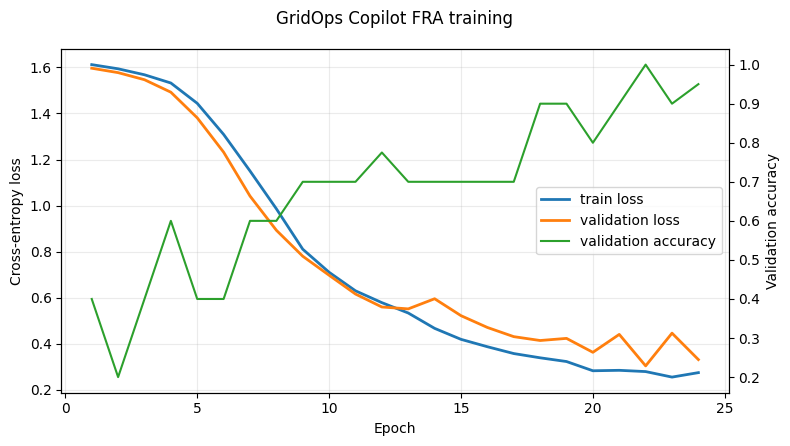

Saved: plots/fra_training_curve.png


In [8]:
PLOTS_DIR = REPO_ROOT / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
epochs = np.arange(1, EPOCHS + 1)
fig, loss_axis = plt.subplots(figsize=(8, 4.5))
loss_axis.plot(epochs, history["train_loss"], label="train loss", linewidth=2)
loss_axis.plot(epochs, history["validation_loss"], label="validation loss", linewidth=2)
loss_axis.set_xlabel("Epoch")
loss_axis.set_ylabel("Cross-entropy loss")
loss_axis.grid(alpha=0.25)
accuracy_axis = loss_axis.twinx()
accuracy_axis.plot(
    epochs, history["validation_accuracy"], label="validation accuracy", color="tab:green"
)
accuracy_axis.set_ylabel("Validation accuracy")
lines = loss_axis.lines + accuracy_axis.lines
loss_axis.legend(lines, [line.get_label() for line in lines], loc="center right")
fig.suptitle("GridOps Copilot FRA training")
fig.tight_layout()
training_plot_path = PLOTS_DIR / "fra_training_curve.png"
fig.savefig(training_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", training_plot_path.relative_to(REPO_ROOT))

Evaluation scope: grouped synthetic holdout; not field generalization.
Grouped synthetic holdout accuracy: 1.0000
Grouped synthetic holdout macro F1: 1.0000
                                          precision    recall  f1-score   support

                                 healthy       1.00      1.00      1.00         8
           winding_deformation_suspected       1.00      1.00      1.00         8
           core_clamping_issue_suspected       1.00      1.00      1.00         8
insulation_related_abnormality_suspected       1.00      1.00      1.00         8
                      needs_human_review       1.00      1.00      1.00         8

                                accuracy                           1.00        40
                               macro avg       1.00      1.00      1.00        40
                            weighted avg       1.00      1.00      1.00        40



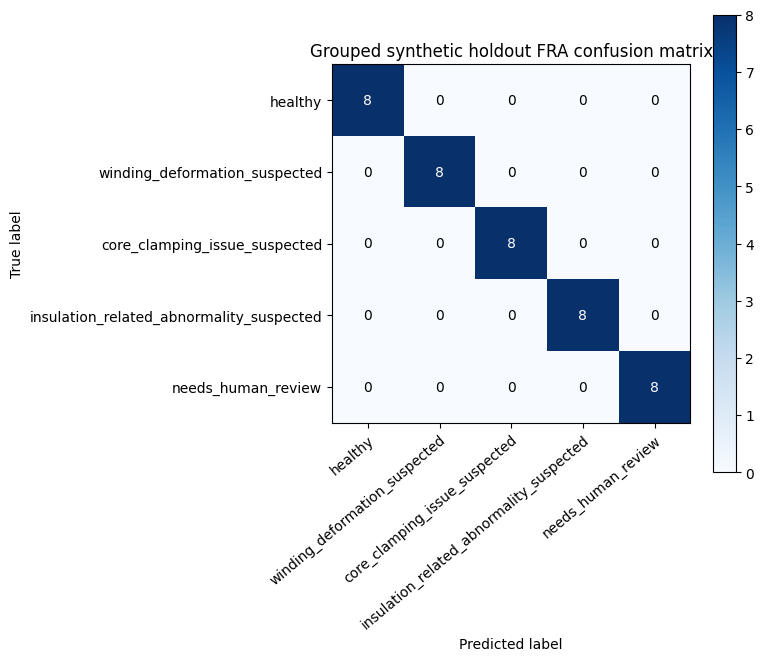

Saved: plots/fra_confusion_matrix.png


In [9]:
model.eval()
y_true = []
y_predicted = []
with torch.inference_mode():
    for features, labels in test_loader:
        logits = model(features.to(DEVICE))
        y_predicted.extend(logits.argmax(dim=1).cpu().tolist())
        y_true.extend(labels.tolist())

accuracy = accuracy_score(y_true, y_predicted)
macro_f1 = f1_score(y_true, y_predicted, average="macro", zero_division=0)
class_report = classification_report(
    y_true,
    y_predicted,
    labels=list(range(len(LABELS))),
    target_names=LABELS,
    zero_division=0,
    output_dict=True,
)
class_report_text = classification_report(
    y_true,
    y_predicted,
    labels=list(range(len(LABELS))),
    target_names=LABELS,
    zero_division=0,
)
confusion = confusion_matrix(y_true, y_predicted, labels=list(range(len(LABELS))))
print("Evaluation scope: grouped synthetic holdout; not field generalization.")
print(f"Grouped synthetic holdout accuracy: {accuracy:.4f}")
print(f"Grouped synthetic holdout macro F1: {macro_f1:.4f}")
print(class_report_text)

fig, axis = plt.subplots(figsize=(8, 7))
image = axis.imshow(confusion, interpolation="nearest", cmap="Blues")
fig.colorbar(image, ax=axis)
axis.set(
    xticks=np.arange(len(LABELS)),
    yticks=np.arange(len(LABELS)),
    xticklabels=LABELS,
    yticklabels=LABELS,
    xlabel="Predicted label",
    ylabel="True label",
    title="Grouped synthetic holdout FRA confusion matrix",
)
plt.setp(axis.get_xticklabels(), rotation=40, ha="right", rotation_mode="anchor")
threshold = confusion.max() / 2 if confusion.size else 0
for row in range(confusion.shape[0]):
    for column in range(confusion.shape[1]):
        axis.text(
            column,
            row,
            int(confusion[row, column]),
            ha="center",
            va="center",
            color="white" if confusion[row, column] > threshold else "black",
        )
fig.tight_layout()
confusion_plot_path = PLOTS_DIR / "fra_confusion_matrix.png"
fig.savefig(confusion_plot_path, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", confusion_plot_path.relative_to(REPO_ROOT))

In [10]:
trained_state_dict = {
    name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()
}
benchmark_batch = next(iter(test_loader))[0]

def benchmark(candidate, batch, device, repeats=50):
    candidate = candidate.to(device)
    batch = batch.to(device)
    candidate.eval()
    with torch.inference_mode():
        for _ in range(5):
            _ = candidate(batch)
        if str(device).startswith("cuda"):
            torch.cuda.synchronize()
        start = time.perf_counter()
        for _ in range(repeats):
            _ = candidate(batch)
        if str(device).startswith("cuda"):
            torch.cuda.synchronize()
        end = time.perf_counter()
    return ((end - start) / repeats) * 1000

cpu_model = FRA1DCNN(in_channels=3, num_classes=len(LABELS))
cpu_model.load_state_dict(trained_state_dict, strict=True)
cpu_batch_ms = benchmark(cpu_model, benchmark_batch, torch.device("cpu"))
accelerator_batch_ms = None
if GPU_AVAILABLE:
    accelerator_model = FRA1DCNN(in_channels=3, num_classes=len(LABELS))
    accelerator_model.load_state_dict(trained_state_dict, strict=True)
    accelerator_batch_ms = benchmark(
        accelerator_model, benchmark_batch, torch.device("cuda")
    )

speedup = (
    cpu_batch_ms / accelerator_batch_ms
    if accelerator_batch_ms is not None and accelerator_batch_ms > 0
    else None
)
print(f"CPU batch latency: {cpu_batch_ms:.3f} ms ({len(benchmark_batch)} curves)")
if AMD_ROCM_READY:
    print(f"AMD GPU batch latency: {accelerator_batch_ms:.3f} ms")
    print(f"Observed CPU/AMD GPU speedup: {speedup:.2f}x")
elif GPU_AVAILABLE:
    print(f"Non-ROCm accelerator latency: {accelerator_batch_ms:.3f} ms")
    print("This result will not be labeled or exported as AMD evidence.")
else:
    print("AMD GPU benchmark pending: rerun this notebook in an AMD ROCm session.")

CPU batch latency: 3.146 ms (32 curves)
AMD GPU batch latency: 0.280 ms
Observed CPU/AMD GPU speedup: 11.24x


In [11]:
MODEL_DIR = REPO_ROOT / "models"
REPORT_DIR = REPO_ROOT / "reports"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

label_map_path = MODEL_DIR / "fra_label_map.json"
label_map_path.write_text(json.dumps(INDEX_TO_LABEL, indent=2) + "\n", encoding="utf-8")
export_model = FRA1DCNN(in_channels=3, num_classes=len(LABELS))
export_model.load_state_dict(trained_state_dict, strict=True)

if AMD_ROCM_READY:
    model_path = MODEL_DIR / "fra_cnn_rocm.pt"
    # Save the raw state_dict contract expected by the backend loader (not a full model object).
    torch.save(export_model.state_dict(), model_path)
    artifact_hash = hashlib.sha256(model_path.read_bytes()).hexdigest()
    generated_at = datetime.now(timezone.utc).isoformat()
    evidence = {
        "status": "complete",
        "amd_usage_claim": (
            "FRA model trained and benchmarked on an AMD GPU using ROCm PyTorch."
        ),
        "generated_at": generated_at,
        "training_platform": "AMD AI Notebooks / AMD Developer Cloud",
        "framework": "PyTorch ROCm",
        "torch_version": torch.__version__,
        "hip_version": HIP_VERSION,
        "gpu_available": True,
        "amd_rocm_verified": True,
        "device_name": DEVICE_NAME,
        "model_artifact": "models/fra_cnn_rocm.pt",
        "artifact_sha256": artifact_hash,
        "label_map": "models/fra_label_map.json",
        "dataset": {
            "source": (
                "data/synthetic canonical FRA curves expanded into seeded scenario "
                "prototypes with repeated sensor-noise observations"
            ),
            "samples": len(augmented_frames),
            "scenario_groups": len(unique_groups),
            "scenarios_per_class": SCENARIOS_PER_CLASS,
            "observations_per_scenario": OBSERVATIONS_PER_SCENARIO,
            "sequence_length": SEQUENCE_LENGTH,
            "input_channels": ["log_frequency_hz", "magnitude_db", "phase_deg"],
            "classes": list(LABELS),
            "seed": SEED,
            "split_strategy": (
                "two-stage stratified split over unique scenario/prototype IDs; "
                "no group crosses train, validation, or test"
            ),
            "split_group_counts": {
                "train": len(train_groups),
                "validation": len(validation_groups),
                "test": len(test_groups),
            },
            "field_validated": False,
            "field_generalization_claimed": False,
        },
        "training": {
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "duration_seconds": float(training_seconds),
        },
        "metrics": {
            "evaluation_scope": "grouped_synthetic_holdout",
            "interpretation": (
                "Unseen seeded synthetic scenario groups only; these metrics do not "
                "estimate field generalization."
            ),
            "accuracy": float(accuracy),
            "f1_macro": float(macro_f1),
            "classification_report": class_report,
            "confusion_matrix": confusion.tolist(),
        },
        "benchmarks": {
            "batch_size": int(len(benchmark_batch)),
            "repeats": 50,
            "cpu_batch_ms": float(cpu_batch_ms),
            "amd_gpu_batch_ms": float(accelerator_batch_ms),
            "speedup": float(speedup),
        },
        "plots": [
            "plots/fra_training_curve.png",
            "plots/fra_confusion_matrix.png",
        ],
        "safety_notice": (
            "Synthetic-data decision support only; all findings require qualified engineer "
            "confirmation and must never trigger automated control action."
        ),
    }
    evidence_path = REPORT_DIR / "amd_training_evidence.json"
    evidence_path.write_text(json.dumps(evidence, indent=2) + "\n", encoding="utf-8")

    benchmark_report = f"""# AMD ROCm FRA benchmark

Generated: {generated_at}

- Device: `{DEVICE_NAME}`
- PyTorch: `{torch.__version__}`
- HIP runtime: `{HIP_VERSION}`
- Evaluation scope: `grouped synthetic holdout (not field generalization)`
- Grouped synthetic holdout accuracy: `{accuracy:.4f}`
- Grouped synthetic holdout macro F1: `{macro_f1:.4f}`
- CPU batch latency ({len(benchmark_batch)} curves): `{cpu_batch_ms:.3f} ms`
- AMD GPU batch latency ({len(benchmark_batch)} curves): `{accelerator_batch_ms:.3f} ms`
- Observed speedup: `{speedup:.2f}x`
- Artifact SHA-256: `{artifact_hash}`

Train, validation, and test use disjoint seeded synthetic scenario/prototype groups.
These grouped synthetic holdout metrics do not estimate field generalization. The model
is not field validated and provides decision support only; every result requires qualified
engineer confirmation.
"""
    benchmark_path = REPORT_DIR / "amd_benchmark.md"
    benchmark_path.write_text(benchmark_report, encoding="utf-8")
    print("Exported official AMD artifact and evidence:")
    print(" ", model_path.relative_to(REPO_ROOT))
    print(" ", evidence_path.relative_to(REPO_ROOT))
    print(" ", benchmark_path.relative_to(REPO_ROOT))
else:
    smoke_model_path = MODEL_DIR / "fra_cnn_local_smoke.pt"
    torch.save(export_model.state_dict(), smoke_model_path)
    print("Saved only a non-AMD local smoke artifact:", smoke_model_path.relative_to(REPO_ROOT))
    print("TODO: rerun every cell on an AMD ROCm GPU to export fra_cnn_rocm.pt and AMD evidence.")
    print("Existing AMD evidence files, if any, were not overwritten.")

Exported official AMD artifact and evidence:
  models/fra_cnn_rocm.pt
  reports/amd_training_evidence.json
  reports/amd_benchmark.md


In [12]:
artifact_to_validate = (
    MODEL_DIR / "fra_cnn_rocm.pt"
    if AMD_ROCM_READY
    else MODEL_DIR / "fra_cnn_local_smoke.pt"
)
loaded_state_dict = torch.load(artifact_to_validate, map_location="cpu", weights_only=True)
validation_model = FRA1DCNN(in_channels=3, num_classes=len(LABELS))
validation_model.load_state_dict(loaded_state_dict, strict=True)
validation_model.eval()
with torch.inference_mode():
    validation_logits = validation_model(sample_x.unsqueeze(0))
assert validation_logits.shape == (1, len(LABELS))
assert json.loads(label_map_path.read_text(encoding="utf-8")) == INDEX_TO_LABEL
assert train_groups.isdisjoint(validation_groups)
assert train_groups.isdisjoint(test_groups)
assert validation_groups.isdisjoint(test_groups)

if AMD_ROCM_READY:
    saved_evidence = json.loads(
        (REPORT_DIR / "amd_training_evidence.json").read_text(encoding="utf-8")
    )
    assert saved_evidence["amd_rocm_verified"] is True
    assert saved_evidence["hip_version"]
    assert saved_evidence["dataset"]["field_validated"] is False
    assert saved_evidence["dataset"]["field_generalization_claimed"] is False
    assert saved_evidence["metrics"]["evaluation_scope"] == (
        "grouped_synthetic_holdout"
    )
    assert saved_evidence["artifact_sha256"] == hashlib.sha256(
        artifact_to_validate.read_bytes()
    ).hexdigest()
    print("AMD artifact, label map, evidence, hash, and CPU inference contract validated.")
else:
    print("Local artifact and CPU inference contract validated; official AMD evidence remains pending.")

AMD artifact, label map, evidence, hash, and CPU inference contract validated.


## Human submission checklist

After a successful **AMD ROCm** run, verify and retain:

- `models/fra_cnn_rocm.pt` (raw `state_dict`)
- `models/fra_label_map.json`
- `reports/amd_training_evidence.json`
- `reports/amd_benchmark.md`
- `plots/fra_training_curve.png`
- `plots/fra_confusion_matrix.png`
- Screenshots showing the AMD device name, HIP version, training output, and benchmark

Do not describe CPU or non-ROCm results as AMD results. Describe evaluation metrics only as **grouped synthetic holdout** results—not field generalization—and keep `field_validated` false. Review metrics for plausibility, download all outputs, and stop the cloud GPU session to preserve credits.

In [13]:
import json

device_label = "AMD gfx1100 GPU (PCI 1002:744b; 96 compute units)"

evidence_path = REPO_ROOT / "reports" / "amd_training_evidence.json"
evidence = json.loads(evidence_path.read_text(encoding="utf-8"))
evidence["device_name"] = device_label
evidence["device_identification"] = {
    "source": "amd-smi static --asic --gpu 0",
    "market_name_raw": "0x744b",
    "vendor_id": "0x1002",
    "vendor_name": "Advanced Micro Devices Inc. [AMD/ATI]",
    "device_id": "0x744b",
    "compute_units": 96,
    "target_graphics_version": "gfx1100",
}
evidence_path.write_text(
    json.dumps(evidence, indent=2) + "\n",
    encoding="utf-8",
)

benchmark_path = REPO_ROOT / "reports" / "amd_benchmark.md"
benchmark = benchmark_path.read_text(encoding="utf-8")
benchmark = benchmark.replace(
    "- Device: ``",
    f"- Device: `{device_label}`",
)
benchmark_path.write_text(benchmark, encoding="utf-8")

print("Recorded device:", evidence["device_name"])
print("Artifact SHA-256:", evidence["artifact_sha256"])

Recorded device: AMD gfx1100 GPU (PCI 1002:744b; 96 compute units)
Artifact SHA-256: 3bcac0c65d3729b31271d2048c2b9c52411f088f94991c22f2db8bd4df1cd633
